Universidad Torcuato Di Tella

Licenciatura en Tecnología Digital\
**Tecnología Digital VI: Inteligencia Artificial**

# **Taller de análisis de datos**

Resolver las siguientes consignas.

### **Consigna 01**

> En un *data frame* llamado `vuelos`, cargar los datos que se encuentran en el archivo `td6-p02-c-datos-vuelos.txt`, disponible en el Campus Virtual, y observarlos.

In [47]:
import pandas as pd

vuelos = pd.read_csv('td6-p02-c-datos-vuelos.txt', sep=";")
vuelos.head()

,Year,Month,DayofMonth,DayOfWeek,DepTime,CRSDepTime,ArrTime,CRSArrTime,UniqueCarrier,FlightNum,...,TaxiIn,TaxiOut,Cancelled,CancellationCode,Diverted,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay
0,2008,1,3,4,2003.0,1955,2211.0,2225,WN,335,...,4.0,8.0,0,NaN,0,NaN,NaN,NaN,NaN,NaN
1,2008,1,3,4,754.0,735,1002.0,1000,WN,3231,...,5.0,10.0,0,NaN,0,NaN,NaN,NaN,NaN,NaN
2,2008,1,3,4,628.0,620,804.0,750,WN,448,...,3.0,17.0,0,NaN,0,NaN,NaN,NaN,NaN,NaN
3,2008,1,3,4,926.0,930,1054.0,1100,WN,1746,...,3.0,7.0,0,NaN,0,NaN,NaN,NaN,NaN,NaN
4,2008,1,3,4,1829.0,1755,1959.0,1925,WN,3920,...,3.0,10.0,0,NaN,0,2.0,0.0,0.0,0.0,32.0


### **Consigna 02**

> ¿Datos de cuántos vuelos tiene el data frame `vuelos`?

In [48]:
vuelos.shape[0]

3318080

**Respuesta**: COMPLETAR.

### **Consigna 03**

> ¿Cuántas columnas tiene el data frame `vuelos`?

In [49]:
vuelos.shape[1]

28

**Respuesta**: COMPLETAR.

### **Consigna 04**

> Considerar un vuelo como demorado si el valor de `ArrDelay` es superior a 20 min. Teniendo esto en cuenta,
>
> * ¿qué aerolínea (*tip*: aprovechar el diccionario de variables e Internet) tiene la mayor proporción de vuelos demorados?
>
> * Y, ¿en qué aeropuerto de destino es más común (en términos relativos) que haya demoras en el arribo?
>
> *Tip*: qué significa cada código lo pueden encontrar en la siguiente página: https://www.iata.org/en/publications/directories/code-search/.

In [50]:
# Approach con columna booleana Demorado
vuelos['Demorado'] = vuelos['ArrDelay'] > 20
vuelos.groupby('UniqueCarrier')['Demorado'].mean().sort_values(ascending=False)

UniqueCarrier
AA    0.220650
MQ    0.191959
OO    0.149205
WN    0.144385
US    0.141364
Name: Demorado, dtype: float64

In [51]:
# Approach con dos dataframes
vuelos_demorados = vuelos[vuelos['Demorado']]
(vuelos_demorados.groupby('UniqueCarrier').size() / vuelos.groupby('UniqueCarrier').size()).sort_values(ascending=False)

UniqueCarrier
AA    0.220650
MQ    0.191959
OO    0.149205
WN    0.144385
US    0.141364
dtype: float64

**Respuesta**: COMPLETAR.

In [52]:
# Approach con dos dataframes
(vuelos_demorados.groupby('Dest')['Demorado'].value_counts() / vuelos.groupby('Dest')['Demorado'].count()).sort_values(ascending= False)

Dest  Demorado
OTH   True        0.365571
EGE   True        0.356979
GUC   True        0.333333
MQT   True        0.326284
EWR   True        0.310471
                    ...   
IPL   True        0.067951
LWS   True        0.067485
WYS   True        0.060606
BLI   True        0.057851
IYK   True        0.040881
Length: 228, dtype: float64

In [53]:
# Approach columna Demorado
vuelos.groupby('Dest')['Demorado'].mean().sort_values(ascending=False)

Dest
OTH    0.365571
EGE    0.356979
GUC    0.333333
MQT    0.326284
EWR    0.310471
         ...   
WYS    0.060606
BLI    0.057851
IYK    0.040881
OGD    0.000000
CYS    0.000000
Name: Demorado, Length: 230, dtype: float64

**Respuesta**: COMPLETAR.

### **Consigna 05**

> ¿Es más o menos común que haya vuelos demorados los fines de semana respecto a los días de semana?

In [54]:
# Approach con columna Demorado
vuelos['esFinDeSemana'] = vuelos['DayOfWeek'] > 5
vuelos.groupby('esFinDeSemana')['Demorado'].mean()



esFinDeSemana
False    0.167800
True     0.159824
Name: Demorado, dtype: float64

In [55]:
# Approach con dos dataframes
vuelos_demorados['esFinDeSemana'] = vuelos_demorados['DayOfWeek'] > 5
(vuelos_demorados.groupby('esFinDeSemana').size() / vuelos.groupby('esFinDeSemana').size()).sort_values(ascending= False)

esFinDeSemana
False    0.167800
True     0.159824
dtype: float64

**Respuesta**: COMPLETAR.

### **Consigna 06**

> Para los casos en que hay minutos de demora debido al clima, ¿cuál es la duración promedio de esas demoras? *Tip*: piensen si, para resolver esta consigna, tiene o no sentido considerar los ceros.

In [56]:
print("Considerando 0s: ", vuelos['WeatherDelay'].mean())
print("Sin considerar 0s: ", vuelos[(vuelos['WeatherDelay'] != 0)]['WeatherDelay'].mean())

Considerando 0s:  2.5629543505917787
Sin considerar 0s:  41.220588235294116


**Respuesta**: COMPLETAR.

### **Consigna 07**

> * ¿Cuáles son el número de vuelo, el origen y el destino correspondientes al vuelo más largo, en términos de tiempo, que se registra en los datos?
>
> * ¿Cuál es la duración, en horas, de dicho vuelo?

In [57]:
vuelos.sort_values('ActualElapsedTime', ascending= False)[['FlightNum', 'Origin', 'Dest','ActualElapsedTime']]

,FlightNum,Origin,Dest,ActualElapsedTime
787074,5,DFW,HNL,727.0
1866718,598,PHL,LAS,681.0
1354549,73,ORD,HNL,650.0
1930072,73,ORD,HNL,625.0
1641642,185,JFK,LAX,618.0
...,...,...,...,...
3317952,2483,BOS,DFW,NaN
3318034,2489,MSY,DFW,NaN
3318053,2491,ORD,AUS,NaN
3318060,2491,ORD,AUS,NaN


**Respuesta**: COMPLETAR.

In [58]:
vuelos.iloc[787074]['ActualElapsedTime'] / 60 # Puedo usar ILOC, LOC, o Maximo del resultado anterior para elegir la fila para la operación.

np.float64(12.116666666666667)

**Respuesta**: COMPLETAR.

### **Consigna 08**

> ¿Cuál es la cantidad de vuelos que se realiza para cada combinación origen-destino? *Tip*: guardar esta información porque es necesaria para resolver la siguiente consigna.

In [59]:
# Creo columna origen-destino
vuelos['Origen-Destino'] = vuelos['Origin'] + '-' + vuelos['Dest']
# Cuantas veces se repite cada origen-destino
vuelos['Origen-Destino'].value_counts()

Origen-Destino
LAX-SAN    11256
SAN-LAX    11222
LAS-PHX    10360
PHX-LAS    10252
DAL-HOU     9790
           ...  
AVP-HPN        1
TWF-BOI        1
LGA-PHL        1
ICT-STL        1
CMI-SPI        1
Name: count, Length: 2799, dtype: int64

**Respuesta**: COMPLETAR.

### **Consigna 09**

> ¿Cuál es el tramo origen-destino para el que se hicieron más vuelos? *Tip*: guardar también esta información porque es necesaria para resolver la siguiente consigna.

In [60]:
vuelos['Origen-Destino'].value_counts().sort_values(ascending= False)

Origen-Destino
LAX-SAN    11256
SAN-LAX    11222
LAS-PHX    10360
PHX-LAS    10252
DAL-HOU     9790
           ...  
FAR-MCI        1
DRO-ABQ        1
BOI-ATW        1
SJC-FAT        1
CMI-SPI        1
Name: count, Length: 2799, dtype: int64

**Respuesta**: COMPLETAR.

### **Consigna 10**

> * Considerando los vuelos correspondientes al tramo más frecuente y que no fueron cancelados, realizar un diagrama de cajas que permita ver la distribución de la duración de los vuelos.
>
> * Una vez hecho el diagrama, ¿a qué consideran que pueden deberse los valores extremos que se visualizan en él?

In [61]:
vuelo_tramo_mas_frecuente = vuelos[(vuelos['Origen-Destino'] == 'LAX-SAN')]
vuelo_tramo_mas_frecuente_sin_cancelados = vuelo_tramo_mas_frecuente[vuelos['Cancelled'] == False]
vuelo_tramo_mas_frecuente_sin_cancelados.head(5)

/var/folders/zn/y37xdg6s17gdnpr34dms7cq80000gn/T/ipykernel_34054/1228865578.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  vuelo_tramo_mas_frecuente_sin_cancelados = vuelo_tramo_mas_frecuente[vuelos['Cancelled'] == False]


,Year,Month,DayofMonth,DayOfWeek,DepTime,CRSDepTime,ArrTime,CRSArrTime,UniqueCarrier,FlightNum,...,CancellationCode,Diverted,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay,Demorado,esFinDeSemana,Origen-Destino
94570,2008,1,1,2,626.0,630,715.0,723,OO,5405,...,NaN,0,NaN,NaN,NaN,NaN,NaN,False,False,LAX-SAN
94572,2008,1,1,2,904.0,829,951.0,922,OO,5407,...,NaN,0,29.0,0.0,0.0,0.0,0.0,True,False,LAX-SAN
94574,2008,1,1,2,859.0,900,947.0,953,OO,5408,...,NaN,0,NaN,NaN,NaN,NaN,NaN,False,False,LAX-SAN
94576,2008,1,1,2,958.0,1000,1051.0,1053,OO,5409,...,NaN,0,NaN,NaN,NaN,NaN,NaN,False,False,LAX-SAN
94578,2008,1,1,2,1037.0,1029,1125.0,1122,OO,5410,...,NaN,0,NaN,NaN,NaN,NaN,NaN,False,False,LAX-SAN


In [62]:
vuelo_tramo_mas_frecuente_sin_cancelados['ActualElapsedTime']

94570      49.0
94572      47.0
94574      48.0
94576      53.0
94578      48.0
           ... 
3237468    49.0
3237469    59.0
3237470    49.0
3237471    46.0
3237473    55.0
Name: ActualElapsedTime, Length: 11128, dtype: float64

In [63]:
vuelo_tramo_mas_frecuente_sin_cancelados['ActualElapsedTime'].values

array([49., 47., 48., ..., 49., 46., 55.], shape=(11128,))

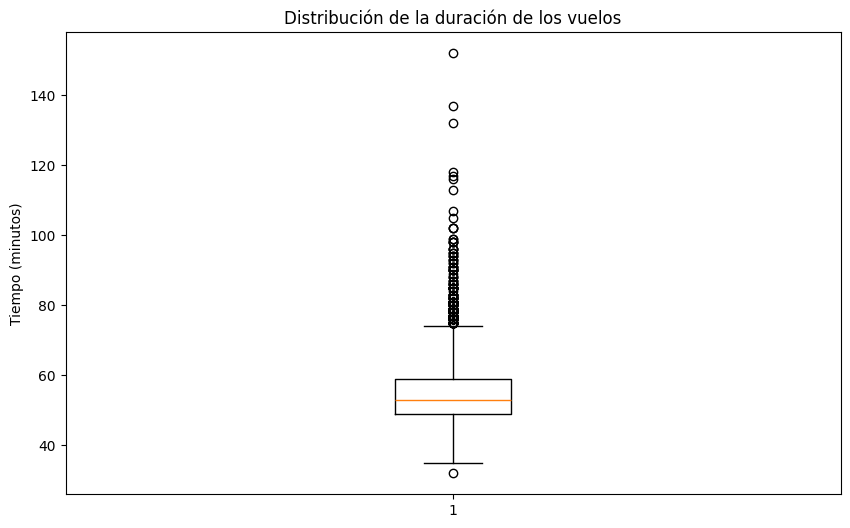

In [64]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.boxplot(vuelo_tramo_mas_frecuente_sin_cancelados['ActualElapsedTime'].dropna())
plt.title('Distribución de la duración de los vuelos')
plt.ylabel('Tiempo (minutos)')
plt.show()

In [65]:
vuelo_tramo_mas_frecuente_sin_cancelados[vuelo_tramo_mas_frecuente_sin_cancelados['ActualElapsedTime'] > 100]

,Year,Month,DayofMonth,DayOfWeek,DepTime,CRSDepTime,ArrTime,CRSArrTime,UniqueCarrier,FlightNum,...,CancellationCode,Diverted,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay,Demorado,esFinDeSemana,Origen-Destino
190826,2008,1,5,6,920.0,925,1117.0,1030,MQ,3055,...,NaN,0,0.0,0.0,47.0,0.0,0.0,True,True,LAX-SAN
190848,2008,1,27,7,1110.0,925,1252.0,1030,MQ,3055,...,NaN,0,73.0,0.0,37.0,0.0,32.0,True,True,LAX-SAN
191011,2008,1,4,5,616.0,620,801.0,722,MQ,3063,...,NaN,0,0.0,0.0,39.0,0.0,0.0,True,False,LAX-SAN
463808,2008,2,3,7,1136.0,1115,1353.0,1217,MQ,3045,...,NaN,0,2.0,0.0,75.0,0.0,19.0,True,True,LAX-SAN
463825,2008,2,20,3,1111.0,1115,1309.0,1217,MQ,3045,...,NaN,0,0.0,0.0,52.0,0.0,0.0,True,False,LAX-SAN
463934,2008,2,14,4,1231.0,1205,1413.0,1310,MQ,3049,...,NaN,0,0.0,0.0,63.0,0.0,0.0,True,False,LAX-SAN
1506693,2008,6,4,3,1807.0,1805,1954.0,1857,OO,5583,...,NaN,0,2.0,0.0,55.0,0.0,0.0,True,False,LAX-SAN
2173705,2008,8,9,6,2237.0,2230,19.0,2325,MQ,3111,...,NaN,0,7.0,0.0,47.0,0.0,0.0,True,True,LAX-SAN
2721460,2008,10,21,2,810.0,800,1003.0,850,MQ,3197,...,NaN,0,0.0,10.0,63.0,0.0,0.0,True,False,LAX-SAN
3235741,2008,12,15,1,1435.0,1350,1707.0,1440,MQ,3001,...,NaN,0,0.0,0.0,102.0,0.0,45.0,True,False,LAX-SAN


**Respuesta**: COMPLETAR.

### **Consigna 11**

> Hacer una figura que permita ver si la distribución de la duración de los vuelos considerados en la consigna anterior varía o no en función de si ocurre un día o de semana o de fin de semana y comentarla.

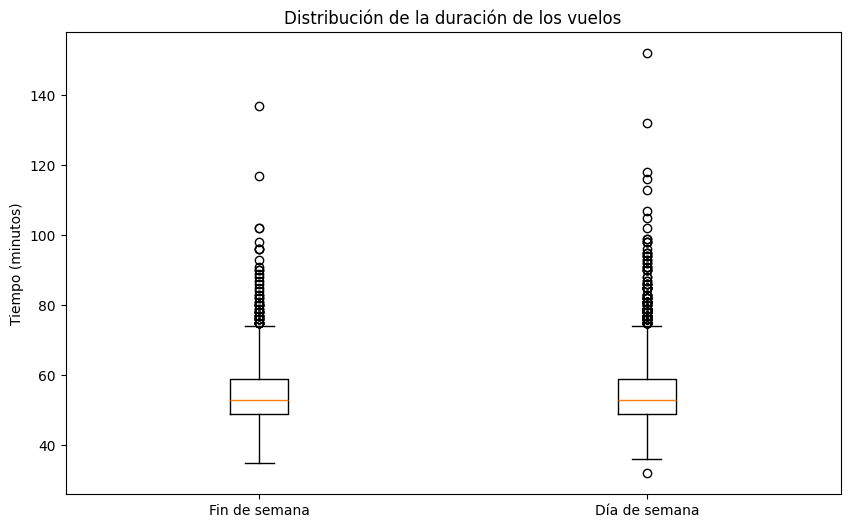

In [66]:
plt.figure(figsize=(10, 6))
cajas = [
    vuelo_tramo_mas_frecuente_sin_cancelados[vuelo_tramo_mas_frecuente_sin_cancelados['esFinDeSemana'] == True]['ActualElapsedTime'].dropna(),
    vuelo_tramo_mas_frecuente_sin_cancelados[vuelo_tramo_mas_frecuente_sin_cancelados['esFinDeSemana'] == False]['ActualElapsedTime'].dropna(),
]
plt.boxplot(cajas)
plt.title('Distribución de la duración de los vuelos')
plt.ylabel('Tiempo (minutos)')
plt.xticks([1, 2], ['Fin de semana', 'Día de semana'])
plt.show()

**Respuesta**: COMPLETAR.

### **Consigna 12**

> Hacer una figura que permita ver, por mes, cuántos vuelos tienen demora en la salida y cuántos, en el arribo y comentarla.

In [67]:
vuelos_demorados_arribo = vuelos[vuelos['ArrDelay'] > 0]
vuelos_demorados_salida = vuelos[vuelos['DepDelay'] > 0]
vuelos_demorados_arribo_por_mes = vuelos_demorados_arribo.groupby('Month')['ArrDelay'].count()
vuelos_demorados_salida_por_mes = vuelos_demorados_salida.groupby('Month')['DepDelay'].count()


In [68]:
vuelos_demorados_arribo.groupby('Month')['ArrDelay'].count()

Month
1     131300
2     128956
3     135577
4     115748
5     119617
6     134975
7     113667
8     105670
9      79435
10     83936
11     78036
12    128955
Name: ArrDelay, dtype: int64

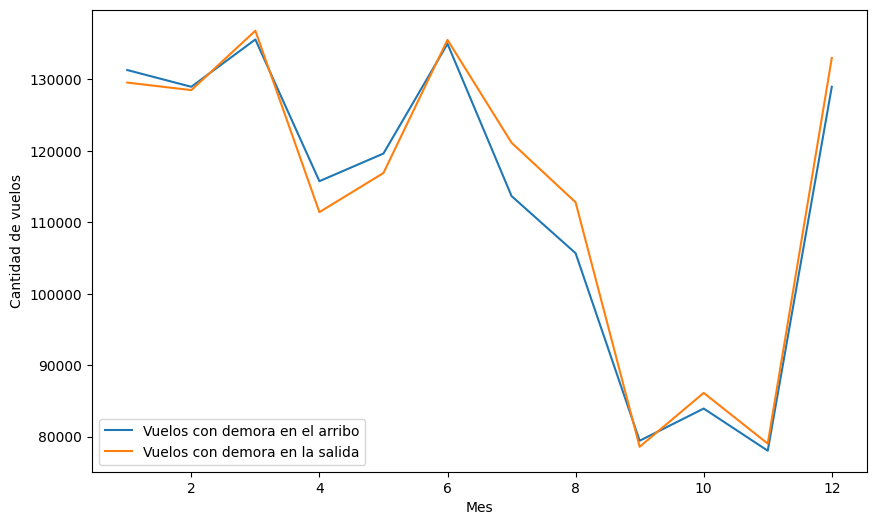

In [69]:
plt.figure(figsize=(10, 6))
plt.plot(vuelos_demorados_arribo_por_mes.index, vuelos_demorados_arribo_por_mes.values, label='Vuelos con demora en el arribo')
plt.plot(vuelos_demorados_salida_por_mes.index, vuelos_demorados_salida_por_mes.values, label='Vuelos con demora en la salida')
plt.xlabel('Mes')
plt.ylabel('Cantidad de vuelos')
plt.legend()
plt.show()

**Respuesta**: COMPLETAR.